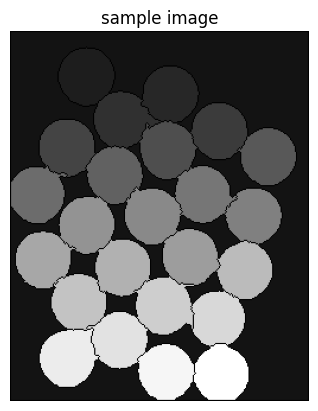

'\n\nunique, counts = np.unique(markers, return_counts=True)\nprint(dict(zip(unique, counts)))\nprint(markers.shape)\nnp.savetxt(\'markers_output.csv\', markers, delimiter=\',\', fmt=\'%d\')\nplt.imshow(markers)\nplt.title("markers")\nplt.show()\nplt.imshow(boundary)\nplt.title("boundary")\nplt.show()\n\n\nfig, axs = plt.subplots(2, 4, figsize=(10, 5))\naxs[0, 0].imshow(thresh, cmap=\'gray\')\naxs[0, 0].set_title(\'Initial Image\')\naxs[0, 0].axis(\'off\')\naxs[0, 1].imshow(opening, cmap=\'gray\')\naxs[0, 1].set_title(\'opening Image\')\naxs[0, 1].axis(\'off\')\naxs[0, 2].imshow(sure_bg, cmap=\'gray\')\naxs[0, 2].set_title(\'sure_bg Image\')\naxs[0, 2].axis(\'off\')\naxs[0, 3].imshow(dist_transform, cmap=\'gray\')\naxs[0, 3].set_title(\'dist_transform Image\')\naxs[0, 3].axis(\'off\')\naxs[1, 0].imshow(sure_fg, cmap=\'gray\')\naxs[1, 0].set_title(\'sure_fg Image\')\naxs[1, 0].axis(\'off\')\naxs[1, 1].imshow(unknown, cmap=\'gray\')\naxs[1, 1].set_title(\'unknown Image\')\naxs[1, 1].axis

In [6]:
import numpy as np
import cv2
from matplotlib import pyplot as plt


img = cv2.imread('Image\water_coins.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

"""
plt.imshow(thresh, cmap='gray')
plt.title('Threshold Image')
plt.show()
"""
# noise removal
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations = 2)
# sure background area
sure_bg = cv2.dilate(opening, kernel, iterations = 3)
# Finding sure foreground area
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.5*dist_transform.max(), 255, 0)
# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
ret, markers = cv2.connectedComponents(sure_fg)
# Add one to all labels so that sure background is not 0, but 1
markers = markers + 1
# Now, mark the region of unknown with zero
markers[unknown == 255] = 0
boundary = cv2.watershed(img, markers)
img[boundary == -1] = [255, 0, 0]

plt.imshow(boundary, cmap='gray')
plt.title("sample image")
plt.axis("off")
plt.show()
"""

unique, counts = np.unique(markers, return_counts=True)
print(dict(zip(unique, counts)))
print(markers.shape)
np.savetxt('markers_output.csv', markers, delimiter=',', fmt='%d')
plt.imshow(markers)
plt.title("markers")
plt.show()
plt.imshow(boundary)
plt.title("boundary")
plt.show()


fig, axs = plt.subplots(2, 4, figsize=(10, 5))
axs[0, 0].imshow(thresh, cmap='gray')
axs[0, 0].set_title('Initial Image')
axs[0, 0].axis('off')
axs[0, 1].imshow(opening, cmap='gray')
axs[0, 1].set_title('opening Image')
axs[0, 1].axis('off')
axs[0, 2].imshow(sure_bg, cmap='gray')
axs[0, 2].set_title('sure_bg Image')
axs[0, 2].axis('off')
axs[0, 3].imshow(dist_transform, cmap='gray')
axs[0, 3].set_title('dist_transform Image')
axs[0, 3].axis('off')
axs[1, 0].imshow(sure_fg, cmap='gray')
axs[1, 0].set_title('sure_fg Image')
axs[1, 0].axis('off')
axs[1, 1].imshow(unknown, cmap='gray')
axs[1, 1].set_title('unknown Image')
axs[1, 1].axis('off')
axs[1, 2].imshow(markers, cmap='gray')
axs[1, 2].set_title('markers Image')
axs[1, 2].axis('off')
axs[1, 3].imshow(boundary)
axs[1, 3].set_title('boundary Image')
axs[1, 3].axis('off')

"""